In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def get_xy_from_pairwise(phist_df: pd.DataFrame, dist_df: pd.DataFrame, vcol):
    df = phist_df.copy()

    needed = {"ID1", "ID2", vcol}
    if not needed.issubset(df.columns):
        raise ValueError(f"phist_df must contain columns {sorted(needed)}; got {list(df.columns)}")

    df = df[df["ID1"] != df["ID2"]].copy()
    df["DIST"] = [dist_df.loc[i, j] for i, j in zip(df["ID1"], df["ID2"])]

    df["DIST"] = pd.to_numeric(df["DIST"], errors="coerce")
    df[vcol] = pd.to_numeric(df[vcol], errors="coerce")
    if vcol == "FST0":
        df[vcol] = df[vcol] / (1 - df[vcol])
    elif vcol == "FST":
        df[vcol] = np.log(df[vcol])
       
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["DIST", vcol])

    return df["DIST"].to_numpy(), df[vcol].to_numpy()

In [3]:
def plot_stat(stats: dict,
              dist_df: pd.DataFrame,
              colors: dict,
              figsize=(5.5, 5),
              dpi=120,
              vcol="PhiST"):
    
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    for chr, stat in stats.items():
        x, y = get_xy_from_pairwise(stat, dist_df, vcol)
        ax.scatter(x, y, s=7, alpha=0.7, color=colors.get(chr, "C0"))
        sns.regplot(x=x, y=y, ax=ax, label=chr, scatter=False, ci=95, color=colors.get(chr, "C0"),
                    line_kws={"linewidth": 2}, truncate=False)

    ax.set_xlabel("Geographic distance (km)", fontsize=18)
    if vcol == "FST":
        ax.set_ylabel(r"log($F_{ST}$)", fontsize=18)
    elif vcol == "FST0":
        ax.set_ylabel(r"$F_{ST}$/(1-$F_{ST}$)", fontsize=18)
    else:
        ax.set_ylabel(r"$\Phi_{ST}$", fontsize=18)
    ax.legend(title=None, frameon=False, fontsize=18)
    plt.tight_layout()
    plt.show()

# Fst

In [ ]:
# compile the stats in one file
basepath = ""
files = {
    ("GSL","AUT"): f"{basepath}/fst_GSL_MF_CM019810.2.csv",
    ("GSL","X"): f"{basepath}/fst_GSL_MF_CM019819.2.csv",
    ("GSL","Y"): f"{basepath}/fst_GSL_M_CM019820.2.csv",
    ("GSL","MT"): f"{basepath}/fst_GSL_MF_CM019821.1.csv",
    ("SSL","AUT"): f"{basepath}/fst_SSL_CM019810.2.csv",
    ("SSL","X"): f"{basepath}/fst_SSL_CM019819.2.csv",
    ("SSL","Y"): f"{basepath}/fst_SSL_CM019820.2.csv",
    ("SSL","MT"): f"{basepath}/fst_SSL_CM019821.1.csv",
}

dfs = []

for (species, chr), file in files.items():
    m = pd.read_csv(file, index_col=0, header=0)
    rows, cols = np.triu_indices_from(m, k=1)

    _df = pd.DataFrame({
        "BY": "pop",
        "SPECIES": species,
        "CHROMOSOME": chr,
        "ID1": m.index[rows],
        "ID2": m.index[cols],
        "FST": m.values[rows, cols]
    })
    dfs.append(_df)

df = pd.concat(dfs, ignore_index=True)
df.to_csv(f"{basepath}/fst_compiled.csv", index=False)



In [ ]:
basepath_dist = ""
df_geo = {
    "GSL": pd.read_csv(f"{basepath_dist}/GSL/gsl_pairwise_depth_weighted_distances_km.csv", index_col=0, header=0),
    "SSL": pd.read_csv(f"{basepath_dist}/SSL/ssl_pairwise_depth_weighted_distances_km.csv", index_col=0, header=0),
}

df = df.loc[df["BY"] == "pop"]
df["FST0"] = df["FST"].clip(lower=0)
bad_ids = ["SMI", "YAMS", "WALR", "WSIS"]

mask = (
    (df["BY"] == "pop") &
    (df["CHROMOSOME"] == "Y") &
    (df["ID1"].isin(bad_ids) | df["ID2"].isin(bad_ids))
)

df = df.loc[~mask].copy()

df_gen = {
    ("Y", "CSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "CSL") & (df["CHROMOSOME"] == "Y")],
    ("MT", "CSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "CSL") & (df["CHROMOSOME"] == "MT")],
    ("X", "CSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "CSL") & (df["CHROMOSOME"] == "X")],
    ("AUT", "CSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "CSL") & (df["CHROMOSOME"] == "AUT")],

    ("Y",  "GSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "GSL") & (df["CHROMOSOME"] == "Y")],
    ("MT", "GSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "GSL") & (df["CHROMOSOME"] == "MT")],
    ("X", "GSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "GSL") & (df["CHROMOSOME"] == "X")],
    ("AUT", "GSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "GSL") & (df["CHROMOSOME"] == "AUT")],

    ("Y",  "SSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "SSL") & (df["CHROMOSOME"] == "Y")],
    ("MT", "SSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "SSL") & (df["CHROMOSOME"] == "MT")],
    ("X", "SSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "SSL") & (df["CHROMOSOME"] == "X")],
    ("AUT", "SSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "SSL") & (df["CHROMOSOME"] == "AUT")]
}

species_colors = {
    "CSL": {"Y": "#fda872", "MT": "#b80604", "X": "#de3f2b", "AUT": "#f4764f"},
    "GSL": {"Y": "#91b5d6", "MT": "#045d92", "X": "#1379b5", "AUT": "#509ac6"},
    "SSL": {"Y": "#d280bd", "MT": "#9f0245", "X": "#d51965", "AUT": "#e4429a"},
}

species_colors_x_aut = {
    "CSL": {"X": "#b80604", "AUT": "#f4764f"},
    "GSL": {"X": "#045d92", "AUT": "#6fb3da"},
    "SSL": {"X": "#770076", "AUT": "#c892cd"},
}

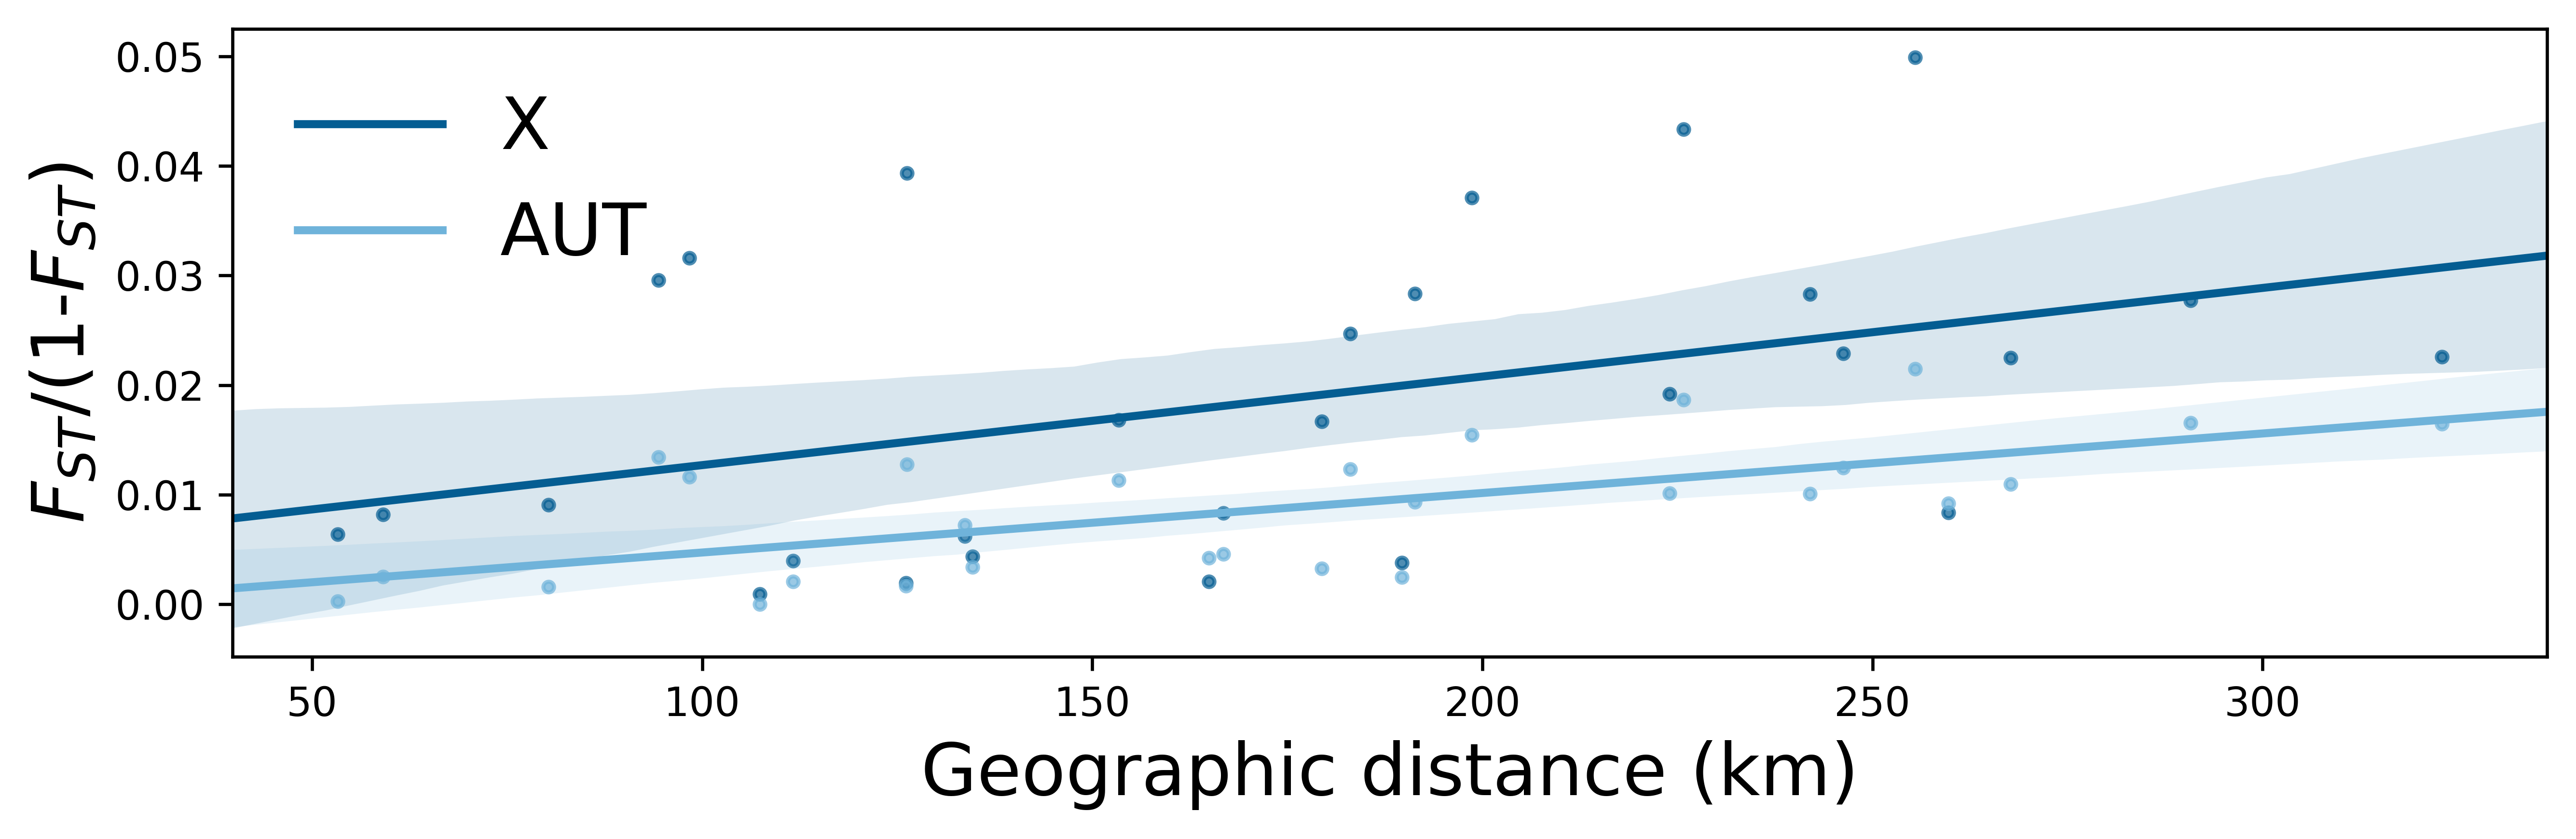

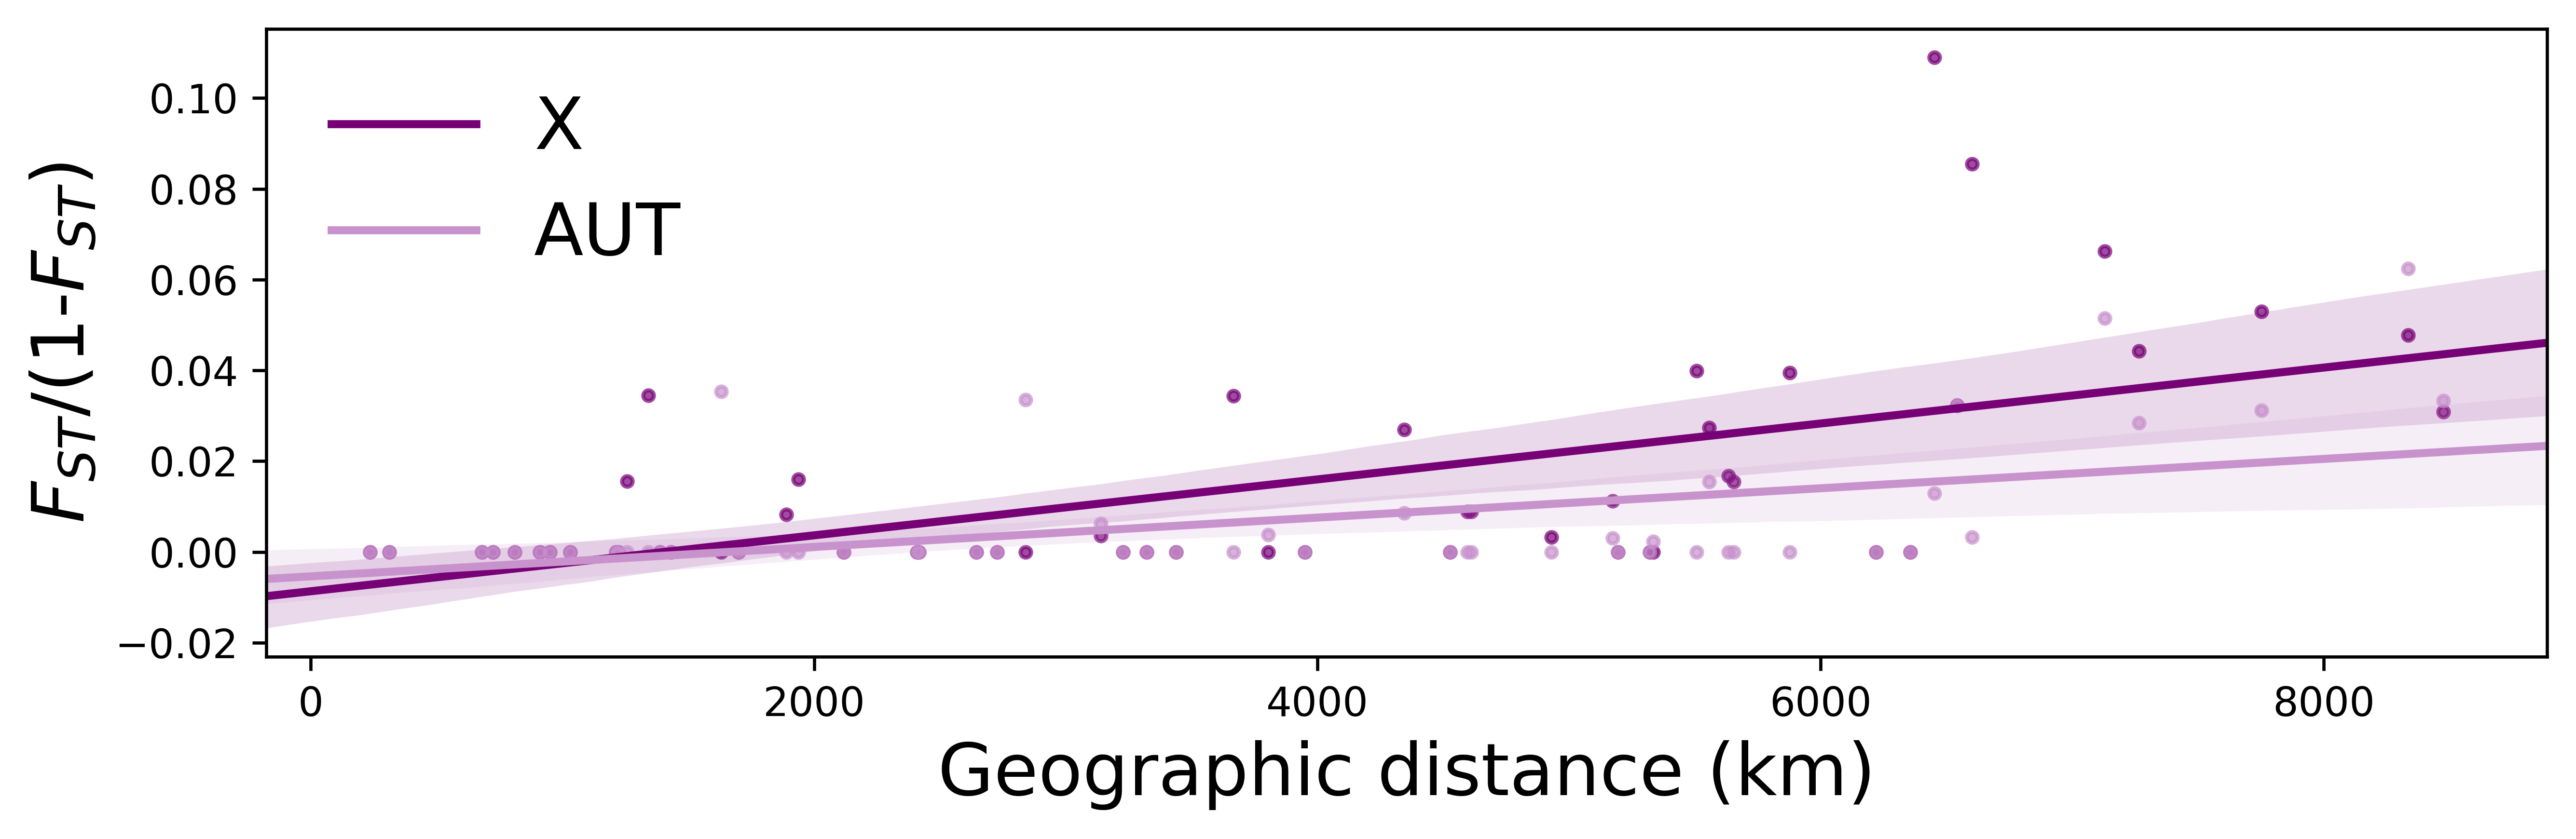

In [11]:
for species in ["GSL", "SSL"]:
    stats={"X": df_gen[("X", species)], "AUT": df_gen[("AUT", species)]}
    plot_stat(stats=stats,
              dist_df=df_geo[species],
              colors=species_colors_x_aut[species],
              figsize=(9, 3),
              dpi=600,
              vcol="FST0")

# PhiST

In [ ]:
df = pd.read_csv(f"{basepath}/Fst/PhiST/compiled_phist.tsv", sep="\t", header=0)
df["PhiST0"] = df["PhiST"].clip(lower=0)
df_gen = {
    ("Y",  "GSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "GSL") & (df["CHROMOSOME"] == "Y")],
    ("MT", "GSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "GSL") & (df["CHROMOSOME"] == "MT")],

    ("Y",  "SSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "SSL") & (df["CHROMOSOME"] == "Y")],
    ("MT", "SSL"): df[(df["BY"] == "pop") & (df["SPECIES"] == "SSL") & (df["CHROMOSOME"] == "MT")]
}

species_colors = {
    "CSL": {"Y": "#fda872", "MT": "#b80604"},
    "GSL": {"Y": "#91b5d6", "MT": "#045d92"},
    "SSL": {"Y": "#d280bd", "MT": "#9f0245"},
}

species_colors_mt_y = {
    "GSL": {"MT": "#045d92", "Y": "#6fb3da"},
    "SSL": {"MT": "#770076", "Y": "#c892cd"},
}

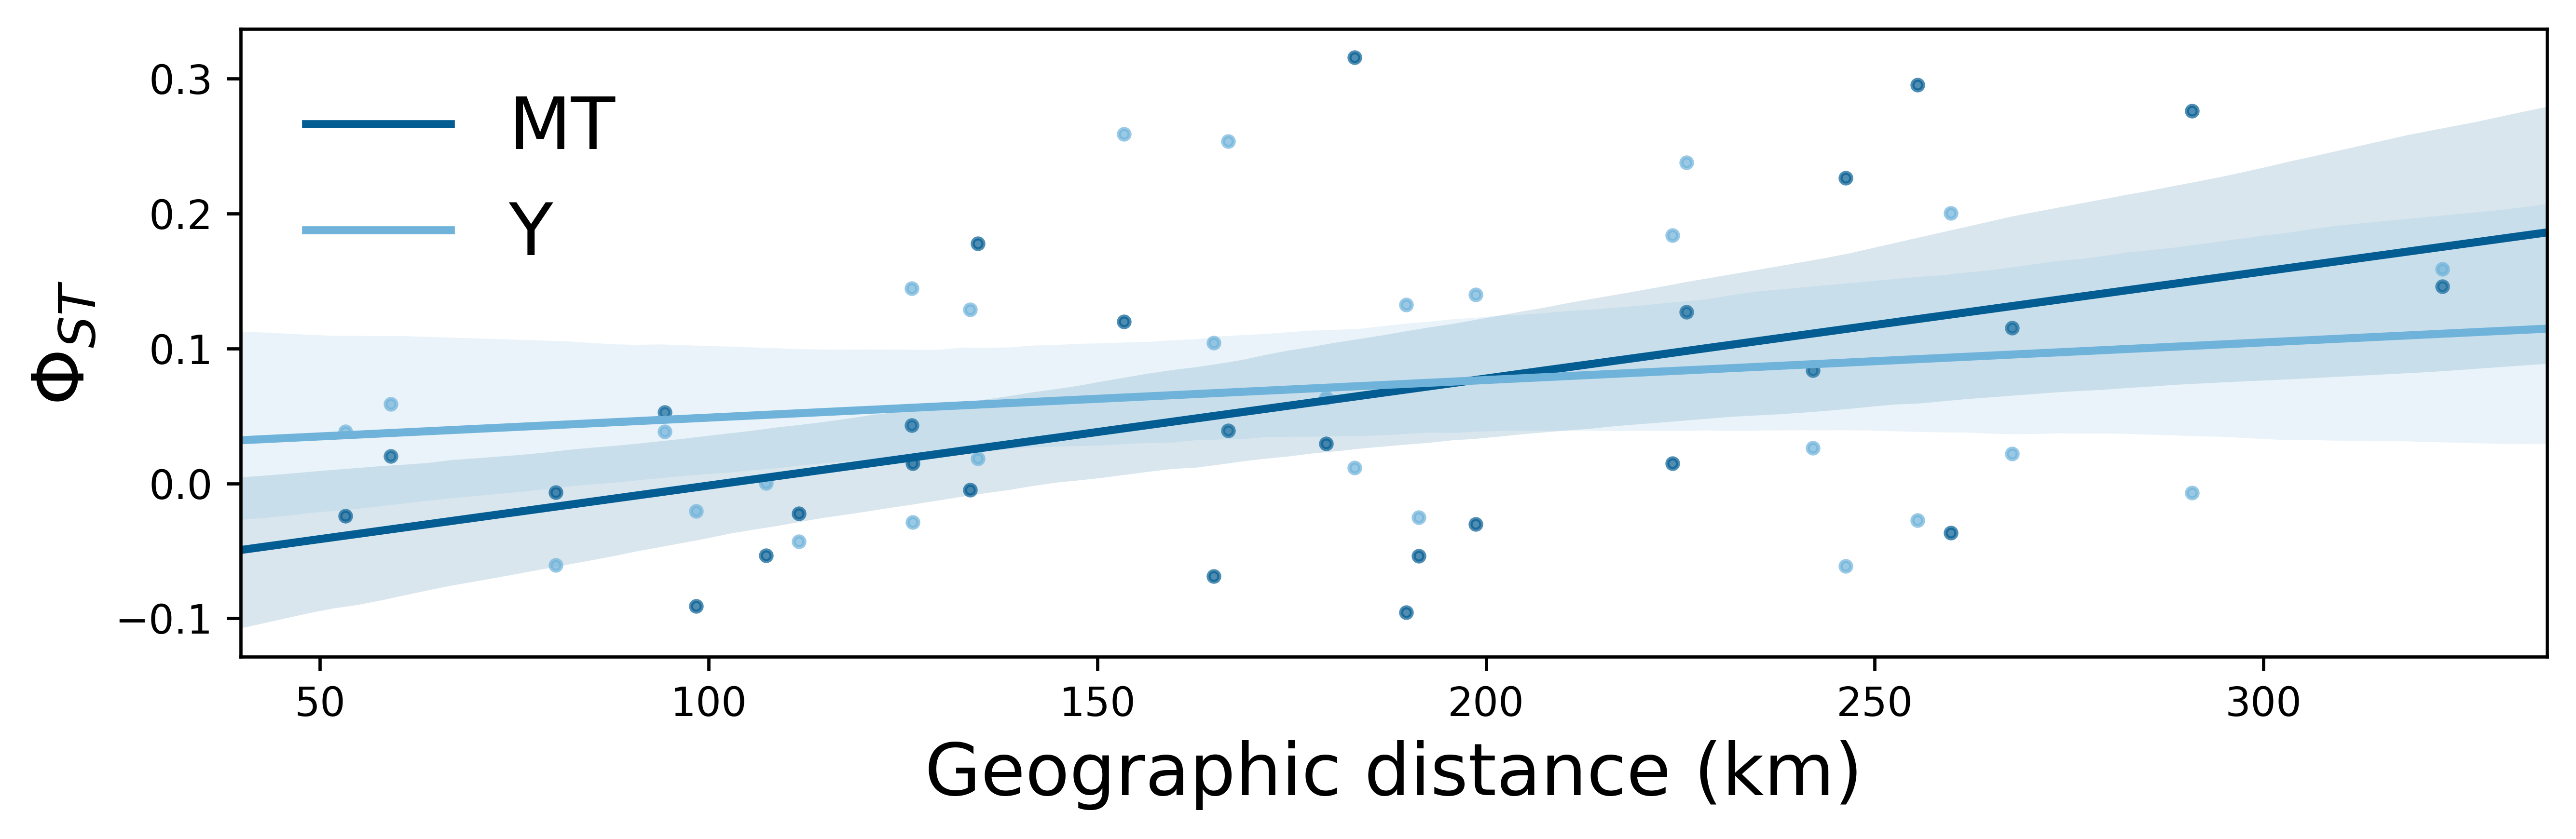

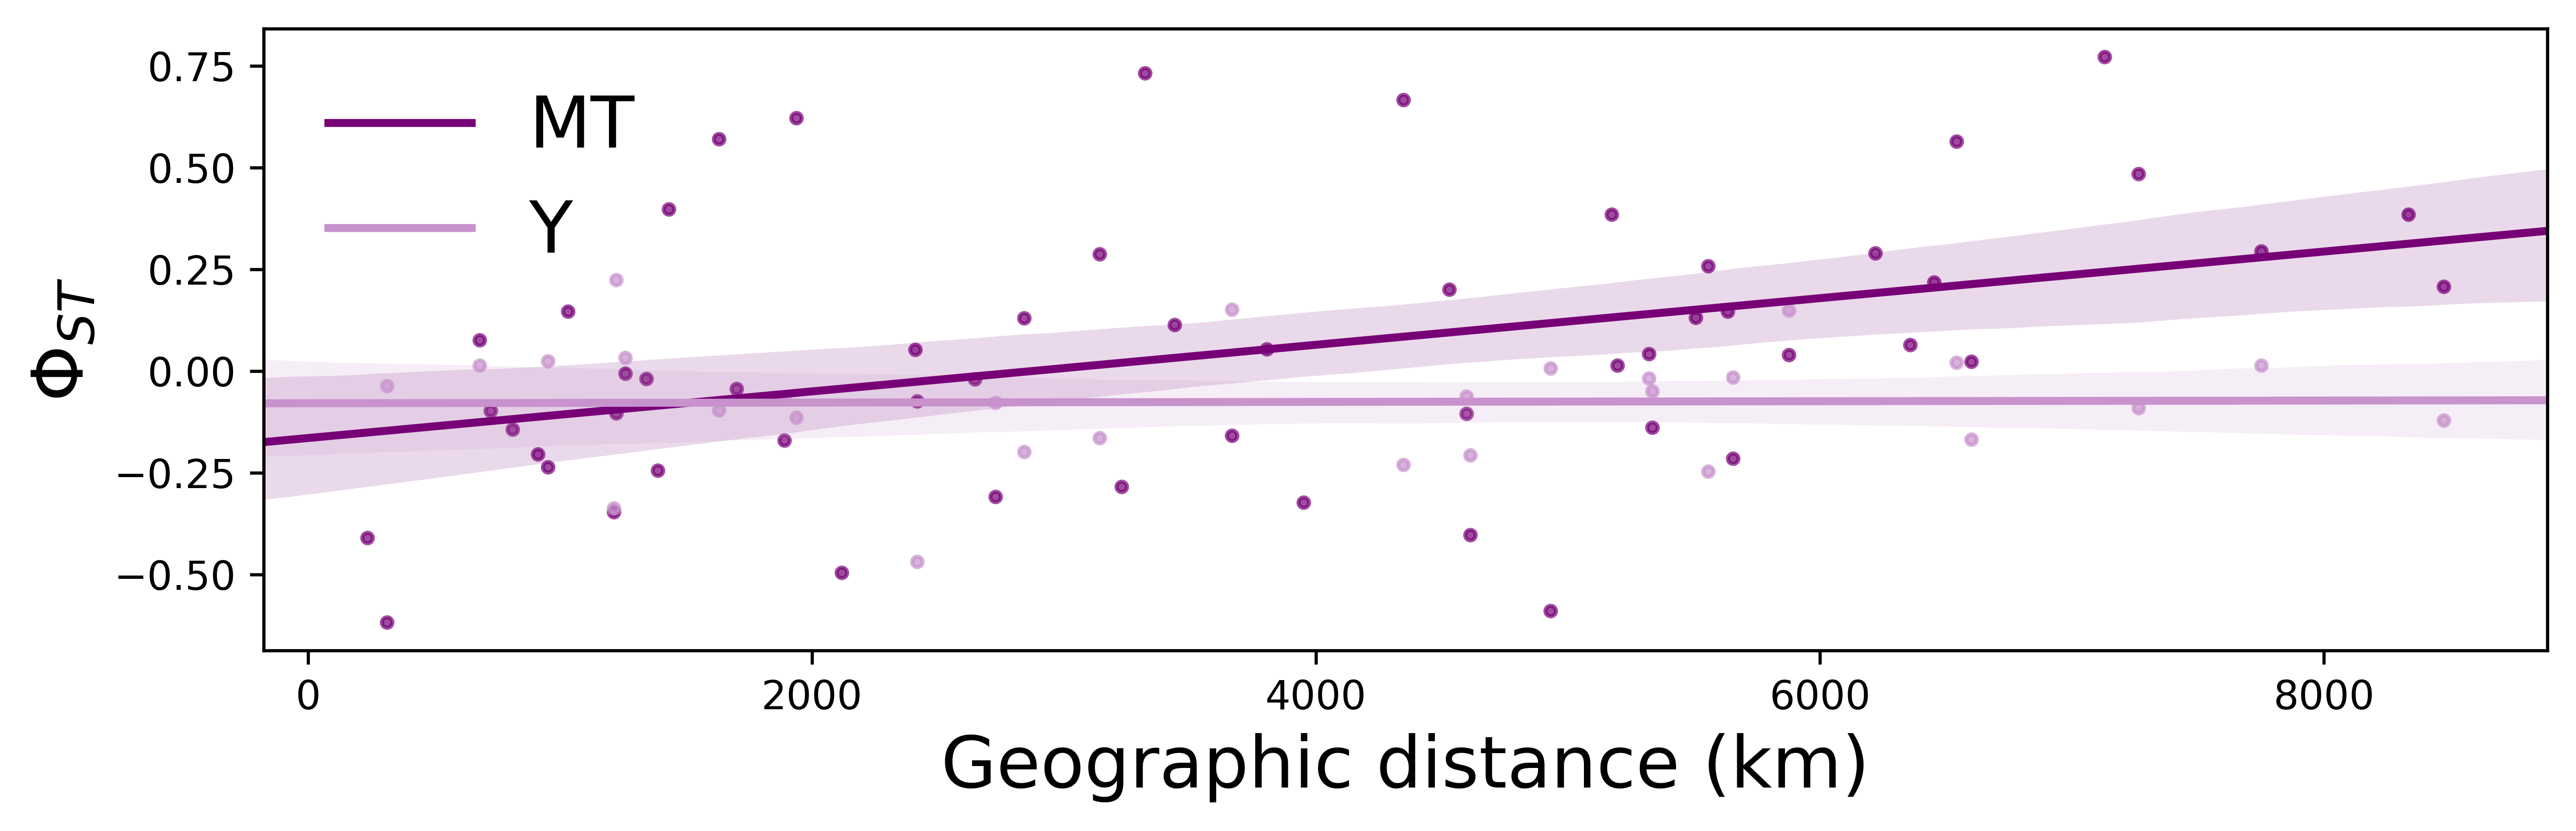

In [13]:
for species in ["GSL", "SSL"]:
    stats={"MT": df_gen[("MT", species)], "Y": df_gen[("Y", species)]}
    plot_stat(stats=stats,
              dist_df=df_geo[species],
              colors=species_colors_mt_y[species],
              figsize=(9, 3),
              dpi=600,
              vcol="PhiST")